From the [Muon Tutorials for Single-cell RNA-seq and ATAC-seq integration](https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/1-Gene-Expression-Processing.html)

In [1]:
# Single-cell packages
import matplotlib.pyplot as plt
import muon as mu
import numpy as np

from pathlib import Path

# General helpful packages for data analysis and visualization
import pandas as pd
import scanpy as sc
import seaborn as sns
from muon import atac as ac  # the module containing function for scATAC data processing

# Setting figure parameters
sc.settings.verbosity = 0

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw" / "mESC_10x_data"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed" / "mESC_10x_data"
SAMPLE_NAME = "E7.5_rep1"

SAMPLE_DATA_DIR = RAW_DATA_DIR / SAMPLE_NAME
SAMPLE_PROCESSED_DATA_DIR = PROCESSED_DATA_DIR / SAMPLE_NAME

if not SAMPLE_PROCESSED_DATA_DIR.exists():
    SAMPLE_PROCESSED_DATA_DIR.mkdir(parents=True)

print(f"Loading data for sample {SAMPLE_NAME} from {RAW_DATA_DIR}...")
# print all files in the data directory
for file in SAMPLE_DATA_DIR.glob("*"):
    print(file)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


Loading data for sample E7.5_rep1 from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data...
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/E7.5_rep1_fragments.sorted.tsv.gz
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/atac_peak_annotation.tsv
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/features.tsv.gz
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/E7.5_rep1_fragments.sorted.tsv.gz.tbi
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/fragments.tsv.gz
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/barcodes.tsv.gz
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_1

In [2]:
mdata = mu.read_10x_mtx(SAMPLE_DATA_DIR)

mdata.write(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:

In [3]:
mdata.var_names_make_unique()
mdata

MuData object with n_obs × n_vars = 8936 × 232170
  var:	'gene_ids', 'feature_types'
  2 modalities
    rna:	8936 x 32285
      var:	'gene_ids', 'feature_types'
    atac:	8936 x 199885
      var:	'gene_ids', 'feature_types'

# RNA

In [4]:
rna = mdata.mod['rna']
rna

AnnData object with n_obs × n_vars = 8936 × 32285
    var: 'gene_ids', 'feature_types'

## Preprocessing

### QC

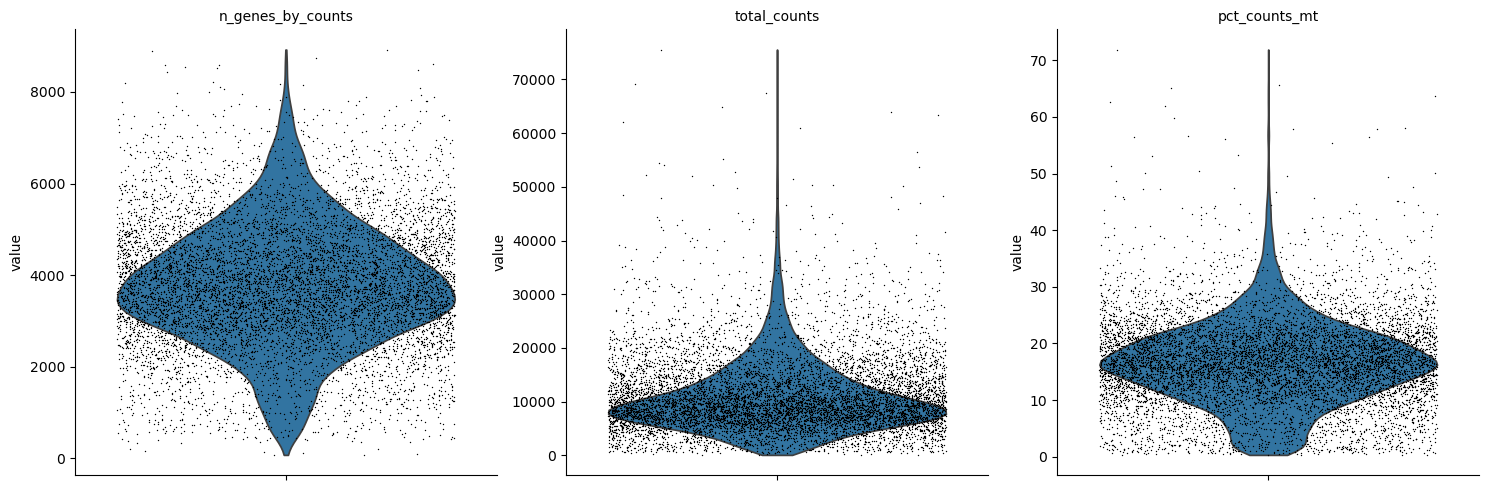

In [5]:
rna.var['mt'] = rna.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

Filter genes and cells based on the thresholds above

In [6]:
MIN_CELLS_PER_GENE = 3

MIN_GENES_PER_CELL = 200
MAX_GENES_PER_CELL = 5000

MAX_TOTAL_COUNTS = 15000
MAX_PCT_COUNTS_MT = 20

mu.pp.filter_var(rna, 'n_cells_by_counts', lambda x: x >= MIN_CELLS_PER_GENE)
mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= MIN_GENES_PER_CELL) & (x <= MAX_GENES_PER_CELL))
mu.pp.filter_obs(rna, 'total_counts', lambda x: x <= MAX_TOTAL_COUNTS)
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x <= MAX_PCT_COUNTS_MT)

Check to see how the data looks after filtering.

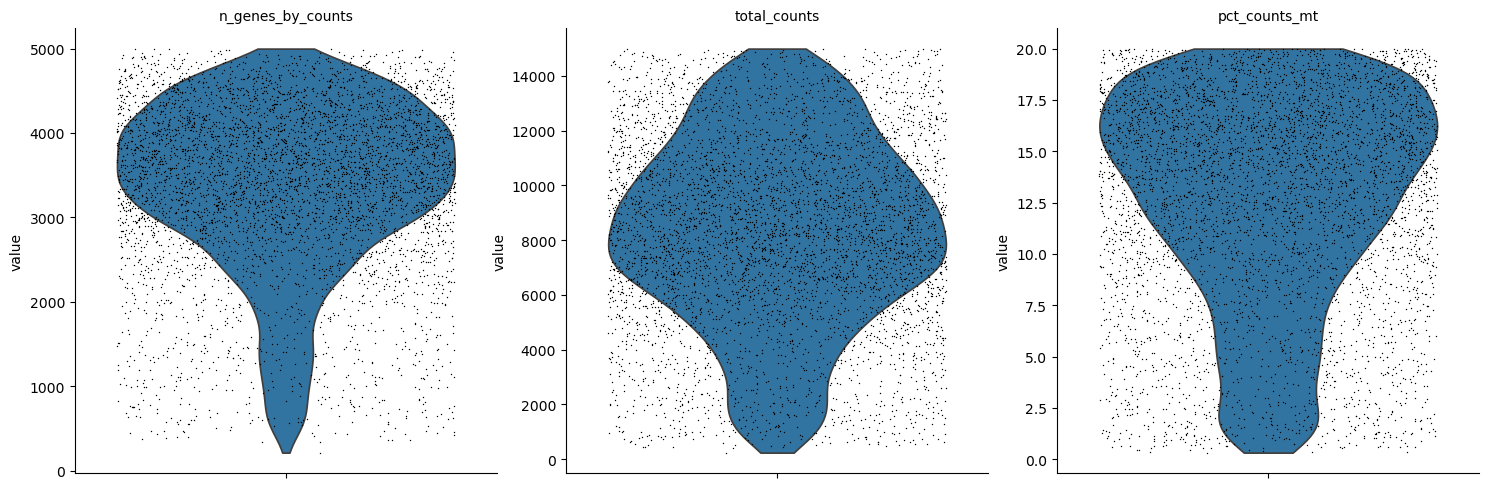

In [7]:
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

### Normalization

In [8]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

### Feature Selection

We will label highly variable genes that we'll use for downstream analysis.

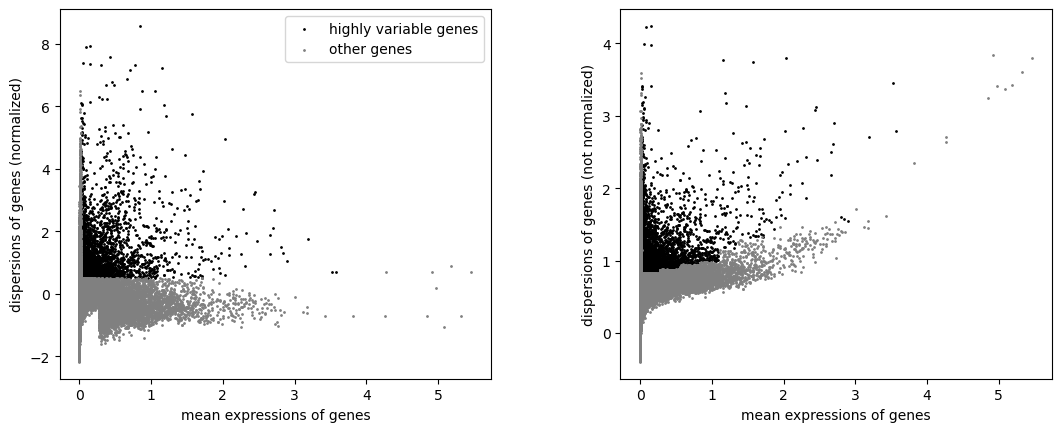

In [9]:
MIN_RNA_DISP = 0.5
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=MIN_RNA_DISP)
sc.pl.highly_variable_genes(rna)

In [10]:
np.sum(rna.var.highly_variable)

np.int64(3310)

### Scaling

We'll save log-normalized counts in a `.raw` slot:

In [11]:
rna.raw = rna

... and scale the log-normalized counts to zero mean and unit variance

In [12]:
sc.pp.scale(rna, max_value=10)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## Analysis

### PCA and Neighborhood Graph

We will visualize some genes that we expect to see in the mESC cells.

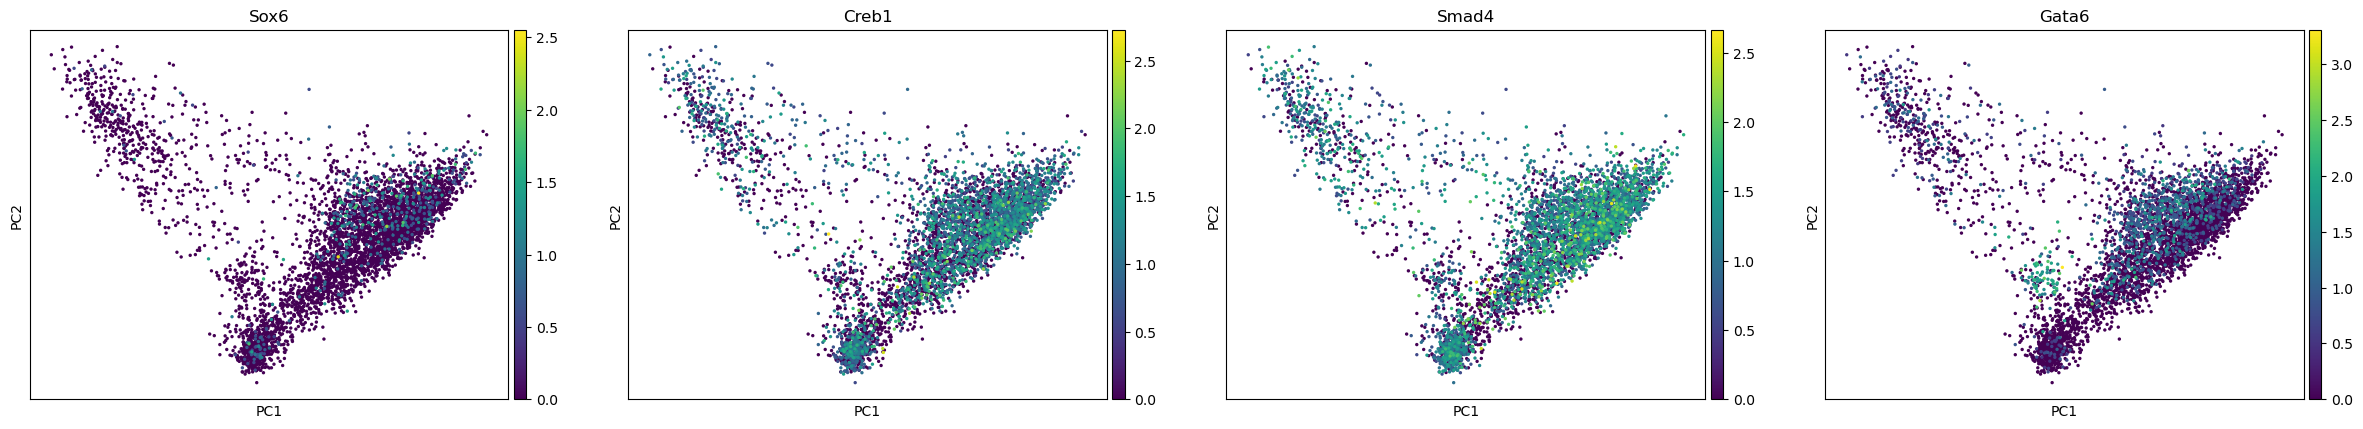

In [13]:
sc.tl.pca(rna, svd_solver='arpack')
sc.pl.pca(rna, color=['Sox6', 'Creb1', 'Smad4', 'Gata6'])

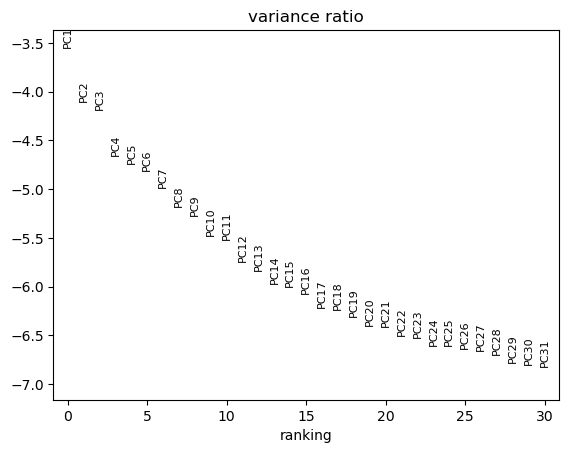

In [14]:
sc.pl.pca_variance_ratio(rna, log=True)

### Neighbors

In [15]:
sc.pp.neighbors(rna, n_neighbors=10, n_pcs=20)

### Non-linear dimensionality reduction and clustering

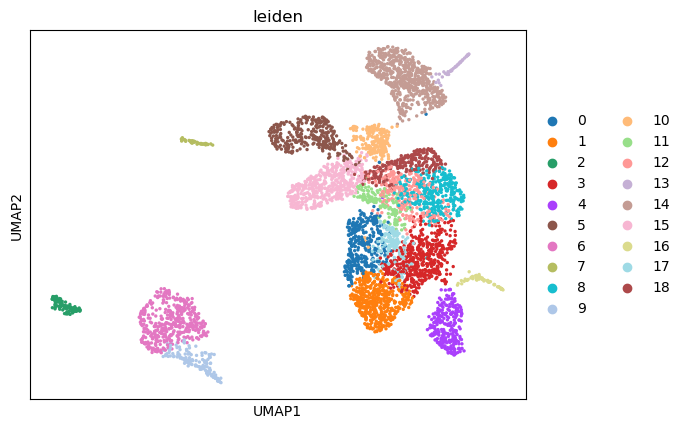

In [16]:
sc.tl.umap(rna, spread=1., min_dist=.5, random_state=11)
sc.tl.leiden(rna, flavor="igraph", n_iterations=2)
sc.pl.umap(rna, color=["leiden"])

## Saving progress to disk

In [17]:
mu.write(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu/rna"), rna)

---

# ATAC

In [18]:
atac = mdata.mod['atac']
atac  # an AnnData object

AnnData object with n_obs × n_vars = 8936 × 199885
    var: 'gene_ids', 'feature_types'

## Preprocessing

### QC

Filter out cells with too few peaks and peaks detected in too few cells.

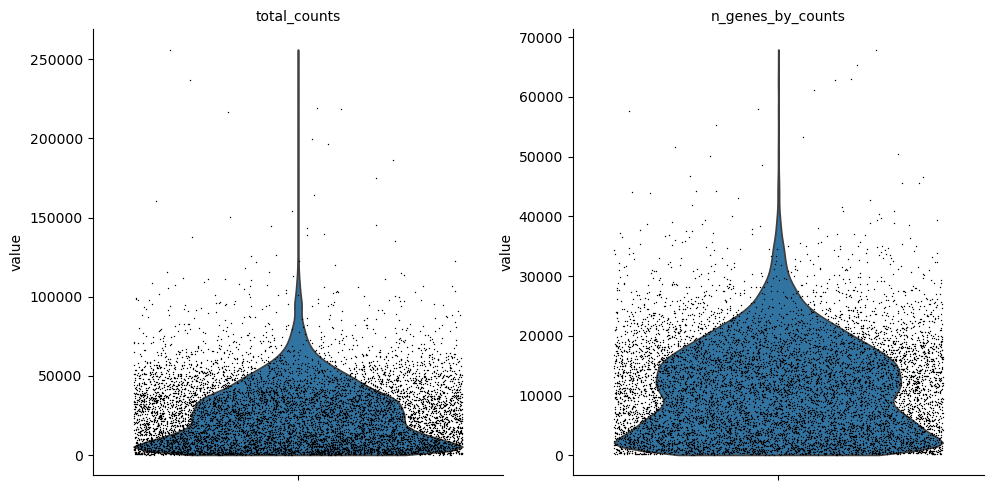

In [19]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(atac, ['total_counts', 'n_genes_by_counts'], jitter=0.4, multi_panel=True)

In [20]:
mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)
# This is analogous to
#   sc.pp.filter_genes(rna, min_cells=10)
# but does in-place filtering and avoids copying the object

mu.pp.filter_obs(atac, 'n_genes_by_counts', lambda x: (x >= 2000) & (x <= 15000))
# This is analogous to
#   sc.pp.filter_cells(atac, max_genes=15000)
#   sc.pp.filter_cells(atac, min_genes=2000)
# but does in-place filtering avoiding copying the object

mu.pp.filter_obs(atac, 'total_counts', lambda x: (x >= 4000) & (x <= 40000))

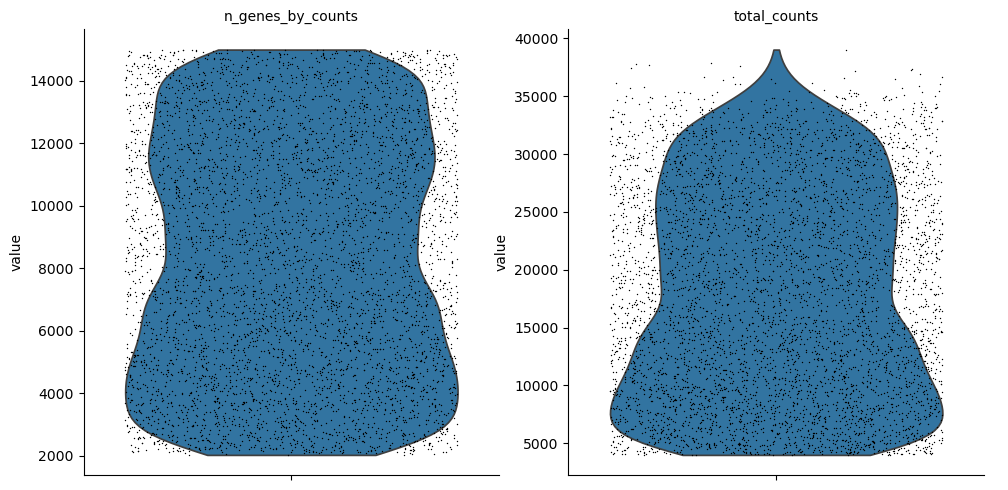

In [21]:
sc.pl.violin(atac, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)


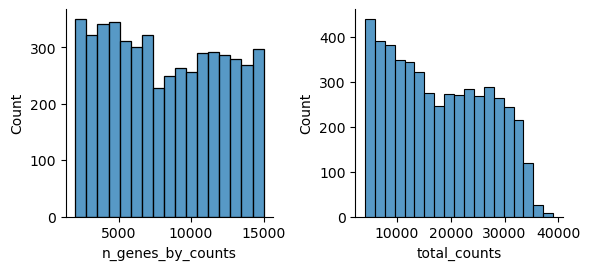

In [22]:
mu.pl.histogram(atac, ['n_genes_by_counts', 'total_counts'])

### ATAC-specific QC
There are a few expectations about how ATAC-seq data looks like as noted in the [hitchhiker’s guide to ATAC-seq data analysis](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-020-1929-3#citeas) for instance


#### Nucleosome Signal

Fragment size distribution typically reflects nucleosome binding pattern showing enrichment around values corresponding to fragments bound to a single nucleosome (between 147 bp and 294 bp) as well as nucleosome-free fragments (shorter than 147 bp).

['GL456210.1', 'GL456211.1', 'GL456212.1', 'GL456216.1', 'GL456219.1', 'GL456221.1', 'GL456233.1', 'GL456350.1', 'GL456354.1', 'JH584292.1', 'JH584295.1', 'JH584296.1', 'JH584297.1', 'JH584299.1', 'JH584304.1', 'chr1', 'chr10', 'chr11', 'chr12', 'chr13']
{'fragments': '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/E7.5_rep1_fragments.sorted.tsv.gz'}
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/mESC_10x_data/E7.5_rep1/E7.5_rep1_fragments.sorted.tsv.gz
chr1:3000000-4000000 chr1	3000081	3000621	AATCCCTGTGTTGCTT-1	1


Fetching Regions...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.36it/s]


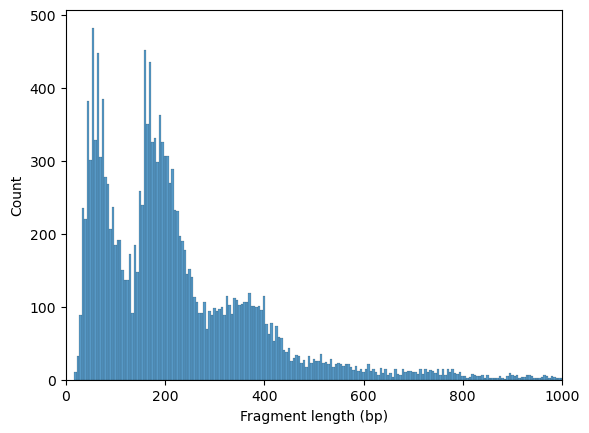

In [23]:
import pysam

frag_path = str(SAMPLE_DATA_DIR / "E7.5_rep1_fragments.sorted.tsv.gz")

tbx = pysam.TabixFile(frag_path)
print(tbx.contigs[:20])

# register the fragment file with the ATAC AnnData
ac.tl.locate_fragments(atac, fragments=frag_path)

print(atac.uns["files"])
print(atac.uns["files"]["fragments"])
# optional grouping column if you want one
atac.obs["NS"] = 1

def find_nonempty_region(tbx, chrom="chr1", window=1_000_000, max_end=200_000_000):
    for start in range(0, max_end, window):
        rows = list(tbx.fetch(chrom, start, start + window))
        if rows:
            return f"{chrom}:{start}-{start+window}", rows[0]
    return None, None

region, example = find_nonempty_region(tbx, chrom="chr1")
print(region, example)

ac.pl.fragment_histogram(atac, region=region)

The ratio of mono-nucleosome cut fragments to nucleosome-free fragments can be called nucleosome signal, and it can be estimated using a subset of fragments.

In [24]:
ac.tl.nucleosome_signal(atac, n=1e6)

Reading Fragments: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:03<00:00, 299930.50it/s]


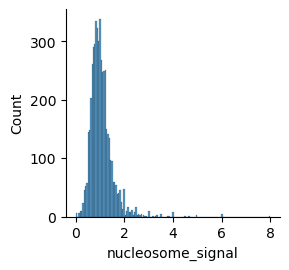

In [25]:
mu.pl.histogram(atac, "nucleosome_signal", kde=False)

#### TSS Enrichment

We can expect chromatin accessibility enriched around transcription start sites (TSS) compared to accessibility of flanking regions. Thus this measure averaged across multiple genes can serve as one more quality control metric.

The positions of transcription start sites can be obtained from the interval field of the gene annotation in the rna modality:

In [26]:
import pandas as pd

tss_path = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/mm10/gene_tss.bed"

# Load BED and rename columns to avoid collisions
tss_df = pd.read_csv(
    tss_path,
    sep="\t",
    header=None,
    names=["tss_chrom", "tss_start", "tss_end", "tss_gene"]
)

var = rna.var.copy()
var["original_var_name"] = var.index

# Match RNA var_names (usually gene symbols) to BED gene column
var = var.merge(
    tss_df,
    left_index=True,
    right_on="tss_gene",
    how="left"
).set_index("original_var_name")

# Build interval only for matched genes
var["interval"] = pd.NA
mask = var["tss_chrom"].notna() & var["tss_start"].notna() & var["tss_end"].notna()

var.loc[mask, "interval"] = (
    var.loc[mask, "tss_chrom"].astype(str) + ":" +
    var.loc[mask, "tss_start"].astype(int).astype(str) + "-" +
    var.loc[mask, "tss_end"].astype(int).astype(str)
)

# Optional: add the exact column names Muon may expect later
var["Chromosome"] = var["tss_chrom"]
var["Start"] = var["tss_start"]
var["End"] = var["tss_end"]

rna.var = var

# keep only genes with TSS annotation
rna_tss = rna[:, rna.var["interval"].notna()].copy()

In [27]:
genes = ac.tl.get_gene_annotation_from_rna(rna_tss)
genes.head(3)

,Chromosome,Start,End,gene_id,gene_name
original_var_name,,,,,
AI597479,chr1,43098709,43098709,ENSMUSG00000010290,AI597479
BC055402,chr1,57214996,57214996,ENSMUSG00000101429,BC055402
AA986860,chr1,130731975,130731975,ENSMUSG00000042510,AA986860


TSS enrichment function will return an AnnData object with cells x bases dimensions where bases correspond to positions around TSS and are defined by extend_upstream and extend_downstream parameters, each of them being 1000 bp by default. It will also record tss_score in the original object.

Fetching Regions...:   0%|                                                                                                                                                                           | 0/141 [00:00<?, ?it/s]

Fetching Regions...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 35.91it/s]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


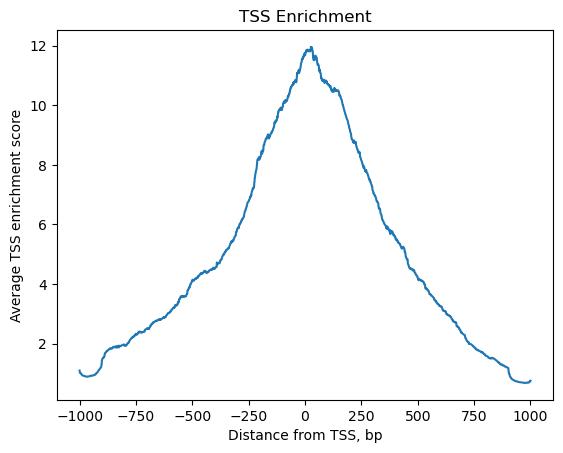

In [28]:
# rna_tss should contain only genes with non-missing interval strings
genes = ac.tl.get_gene_annotation_from_rna(rna_tss)

# now use those features explicitly
tss = ac.tl.tss_enrichment(mdata, features=genes, n_tss=1000)

# plot
ac.pl.tss_enrichment(tss)

### Normalization

In [29]:
# Save original counts
atac.layers["counts"] = atac.X

There can be multiple options for ATAC-seq data normalisation.

One is latent semantic indexing that is frequently used for processing ATAC-seq datasets. First, it constructs term-document matrix from the original count matrix. Then the singular value decomposition (SVD) — the same technique that convential principal component analysis uses — is used to generate LSI components. Note that there are different flavours of computing TF-IDF, e.g. see this blog post about that.

TF-IDF normalisation is implemented in the muon’s ATAC module:

In [30]:
ac.pp.tfidf(atac, scale_factor=1e4)

Here we will use the same log-normalisation and PCA that we are used to from scRNA-seq analysis. We notice on this data it yields PC & UMAP spaces similar to the one generated on scRNA-seq counts.

In [31]:
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)

/tmp/ipykernel_1047223/27188036.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


### Feature Selection

We will label highly variable peaks that we’ll use for downstream analysis.

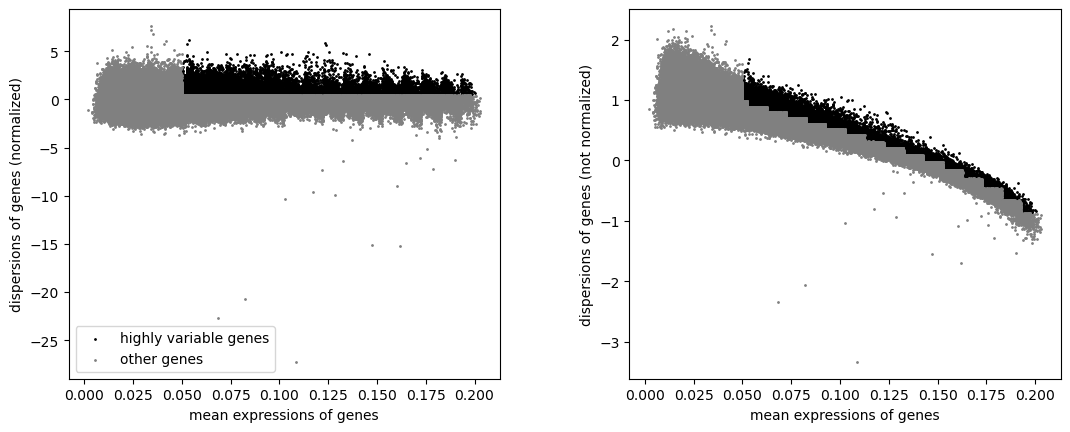

In [32]:
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=.5)
sc.pl.highly_variable_genes(atac)

In [33]:
np.sum(atac.var.highly_variable)

np.int64(16956)

### Scaling

For uniformity, and for consequent visualisation, we’ll save log-transformed counts in a .raw slot:

In [34]:
atac.raw = atac

## Analysis

After filtering out low-quality cells, normalising the counts matrix, and selecting highly variable peaks, we can already use this data for multimodal integration.

However, as in the case of gene expression, we will study this data individually first and will run PCA on the scaled matrix, compute cell neighbourhood graph, and perform clustering to define cell types. This might be useful later to compare cell type definition between modalities.

### LSI

When working on TF-IDF counts, `sc.tl.pca` or `ac.tl.lsi` can be used to get latent components, e.g.:

In [35]:
ac.tl.lsi(atac)

We find the first component is typically associated with number of peaks or counts per cell so it is reasonable to remove it:

In [36]:
atac.obsm['X_lsi'] = atac.obsm['X_lsi'][:,1:]
atac.varm["LSI"] = atac.varm["LSI"][:,1:]
atac.uns["lsi"]["stdev"] = atac.uns["lsi"]["stdev"][1:]

The respective neighbourhood graph can be generated with sc.tl.neighbors:

In [37]:
sc.pp.neighbors(atac, use_rep="X_lsi", n_neighbors=10, n_pcs=30)

### PCA

For this notebook, we are using PCA on the log-normalised counts in atac.X as described above.

In [38]:
sc.pp.scale(atac)
sc.tl.pca(atac)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


We can only colour our plots by cut counts in individual peaks with scanpy:

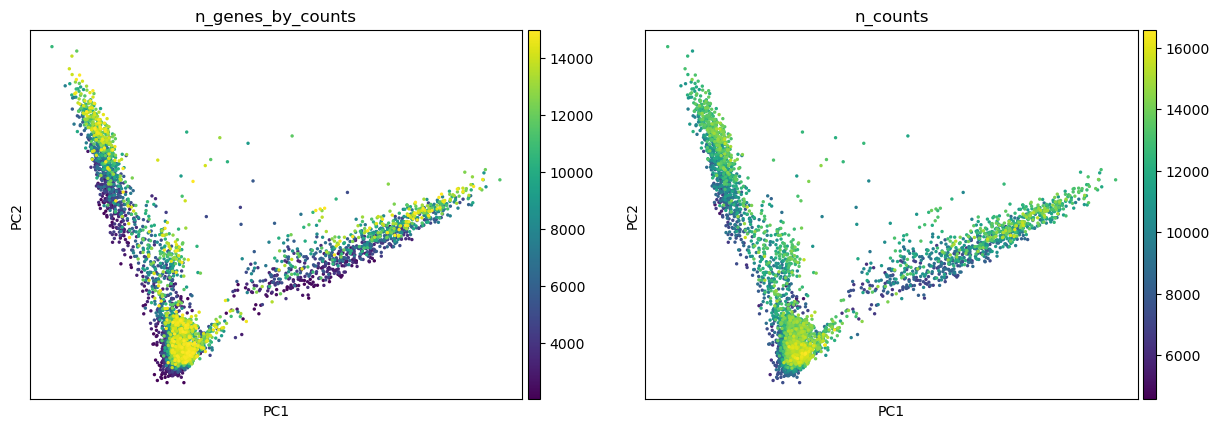

In [39]:
sc.pl.pca(atac, color=["n_genes_by_counts", "n_counts"])

With muon’s ATAC module, we can plot average values for cut counts in peaks of different types (promoter/distal) that are assigned to respective genes — just by providing gene names.

For that to work, we need the peak annotation table with `gene -> peak` correspondence. The `peak_annotation.tsv` file was detected and loaded automatically when we loaded the original data. Here is how the processed peak annotation table looks like:

In [40]:
def construct_peak_annotation(atac, save_dir: Path):
    """Construct a peak annotation table in 10x-style format, assigning each peak to a gene and distance based on TSS proximity."""
    
    # --------------------------------------------------
    # Inputs
    # --------------------------------------------------
    tss_path = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/mm10/gene_tss.bed"

    # 10x-style windows
    PROMOTER_UPSTREAM = 1000
    PROMOTER_DOWNSTREAM = 100
    DISTAL_MAX = 200_000

    # --------------------------------------------------
    # 1. Parse ATAC peaks
    # expects atac.var_names like chr1:1000-1500
    # --------------------------------------------------
    peaks = pd.DataFrame({"peak": atac.var_names.astype(str)})

    coords = peaks["peak"].str.extract(
        r"^(?P<chrom>[^:]+):(?P<start>\d+)-(?P<end>\d+)$"
    )

    if coords.isna().any().any():
        bad = peaks.loc[coords.isna().any(axis=1), "peak"].head(10).tolist()
        raise ValueError(f"Could not parse some peak names. Examples: {bad}")

    peaks = pd.concat([peaks, coords], axis=1)
    peaks["start"] = peaks["start"].astype(int)
    peaks["end"] = peaks["end"].astype(int)

    # --------------------------------------------------
    # 2. Load TSS BED
    # your BED columns are: chrom, start, end, gene symbol
    # --------------------------------------------------
    tss = pd.read_csv(
        tss_path,
        sep="\t",
        header=None,
        names=["chrom", "tss_start", "tss_end", "gene"]
    )

    # TSS BED appears to use a single-base TSS
    # Use tss_start as the TSS coordinate
    tss["tss"] = tss["tss_start"].astype(int)

    # Optional: if you have a protein-coding-only file, use it.
    # Otherwise this step will include all genes in the BED.
    # tss = tss[tss["gene_biotype"] == "protein_coding"].copy()

    # --------------------------------------------------
    # 3. Cross-join peaks and genes by chromosome
    # --------------------------------------------------
    cand = peaks.merge(
        tss[["chrom", "gene", "tss"]],
        on="chrom",
        how="inner"
    )

    # 10x signed distance:
    # positive if peak start is downstream of TSS
    # negative if peak end is upstream of TSS
    # zero if TSS overlaps peak
    cand["distance"] = np.where(
        cand["start"] > cand["tss"],
        cand["start"] - cand["tss"],
        np.where(
            cand["end"] < cand["tss"],
            cand["end"] - cand["tss"],
            0
        )
    )

    cand["abs_distance"] = cand["distance"].abs()

    # --------------------------------------------------
    # 4. PROMOTER peaks:
    # overlap promoter region [TSS-1000, TSS+100]
    # --------------------------------------------------
    cand["is_promoter"] = (
        (cand["end"] >= (cand["tss"] - PROMOTER_UPSTREAM)) &
        (cand["start"] <= (cand["tss"] + PROMOTER_DOWNSTREAM))
    )

    promoter = cand.loc[cand["is_promoter"], ["peak", "chrom", "start", "end", "gene", "distance"]].copy()
    promoter["peak_type"] = "promoter"

    # --------------------------------------------------
    # 5. DISTAL peaks:
    # within 200 kb of the CLOSEST TSS,
    # but not promoter for that same gene
    # --------------------------------------------------
    # find closest TSS gene per peak
    closest_idx = cand.groupby("peak")["abs_distance"].idxmin()
    closest = cand.loc[closest_idx, ["peak", "chrom", "start", "end", "gene", "distance", "abs_distance"]].copy()

    closest = closest.loc[closest["abs_distance"] <= DISTAL_MAX].copy()

    # remove cases where that peak is already promoter for that same gene
    promoter_pairs = set(zip(promoter["peak"], promoter["gene"]))
    closest["is_promoter_same_gene"] = [
        (p, g) in promoter_pairs for p, g in zip(closest["peak"], closest["gene"])
    ]

    distal = closest.loc[~closest["is_promoter_same_gene"], ["peak", "chrom", "start", "end", "gene", "distance"]].copy()
    distal["peak_type"] = "distal"

    # --------------------------------------------------
    # 6. INTERGENIC peaks:
    # peaks with no promoter or distal assignment
    # --------------------------------------------------
    assigned_peaks = set(promoter["peak"]) | set(distal["peak"])

    intergenic = peaks.loc[~peaks["peak"].isin(assigned_peaks), ["peak", "chrom", "start", "end"]].copy()
    intergenic["gene"] = ""
    intergenic["distance"] = np.nan
    intergenic["peak_type"] = "intergenic"

    # --------------------------------------------------
    # 7. Final table in 10x format
    # --------------------------------------------------
    peak_annotation_10x = pd.concat(
        [
            promoter[["chrom", "start", "end", "gene", "distance", "peak_type"]],
            distal[["chrom", "start", "end", "gene", "distance", "peak_type"]],
            intergenic[["chrom", "start", "end", "gene", "distance", "peak_type"]],
        ],
        axis=0,
        ignore_index=True
    ).sort_values(["chrom", "start", "end", "gene", "peak_type"])
    
    peak_annotation_10x = peak_annotation_10x.dropna()

    print(peak_annotation_10x.head(20))
    print(peak_annotation_10x["peak_type"].value_counts(dropna=False))

    # save as 10x-style TSV
    out_path = save_dir / "atac_peak_annotation.tsv"
    peak_annotation_10x.to_csv(out_path, sep="\t", index=False)
    print(f"Saved to {out_path}")

if not (SAMPLE_PROCESSED_DATA_DIR / "atac_peak_annotation.tsv").exists():
    construct_peak_annotation(atac, SAMPLE_DATA_DIR)
else:
    print("Peak annotation already exists, skipping construction.")

      chrom    start      end  gene  distance peak_type
97747  chr1  3477070  3477924  XKR4 -193574.0    distal
97754  chr1  3482645  3483577  XKR4 -187921.0    distal
97774  chr1  3514583  3515479  XKR4 -156019.0    distal
97775  chr1  3549161  3550036  XKR4 -121462.0    distal
97776  chr1  3560226  3561143  XKR4 -110355.0    distal
97777  chr1  3584333  3585135  XKR4  -86363.0    distal
97784  chr1  3592548  3593352  XKR4  -78146.0    distal
97853  chr1  3647339  3648147  XKR4  -23351.0    distal
97854  chr1  3648731  3649633  XKR4  -21865.0    distal
0      chr1  3670465  3671219  XKR4    -279.0  promoter
1      chr1  3671430  3672219  XKR4       0.0  promoter
97901  chr1  3681200  3682108  XKR4    9702.0    distal
97954  chr1  3727593  3728401  XKR4   56095.0    distal
98368  chr1  4213955  4214872   RP1 -145431.0    distal
98369  chr1  4226038  4226926   RP1 -133377.0    distal
98370  chr1  4227899  4228782   RP1 -131521.0    distal
98372  chr1  4255545  4256311   RP1 -103992.0   

In [41]:
ac.tl.add_peak_annotation(atac, annotation=str(SAMPLE_DATA_DIR / "atac_peak_annotation.tsv"))

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_atac/tools.py:118: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  pa.loc[pa.distance.isnull(), "distance"] = ""


In [42]:
atac.uns['atac']['peak_annotation'].tail()

,peak,distance,peak_type
gene,,,
ERDR1,chrY:90807309-90808160,21868,distal
ERDR1,chrY:90808625-90809391,23184,distal
ERDR1,chrY:90812389-90813230,26948,distal
ERDR1,chrY:90824980-90825873,39539,distal
ERDR1,chrY:90828392-90829314,42951,distal


Now we can plot average cut values in peaks corresponding to genes just by providing a gene name. By default, values in `atac.raw` are used for plotting.

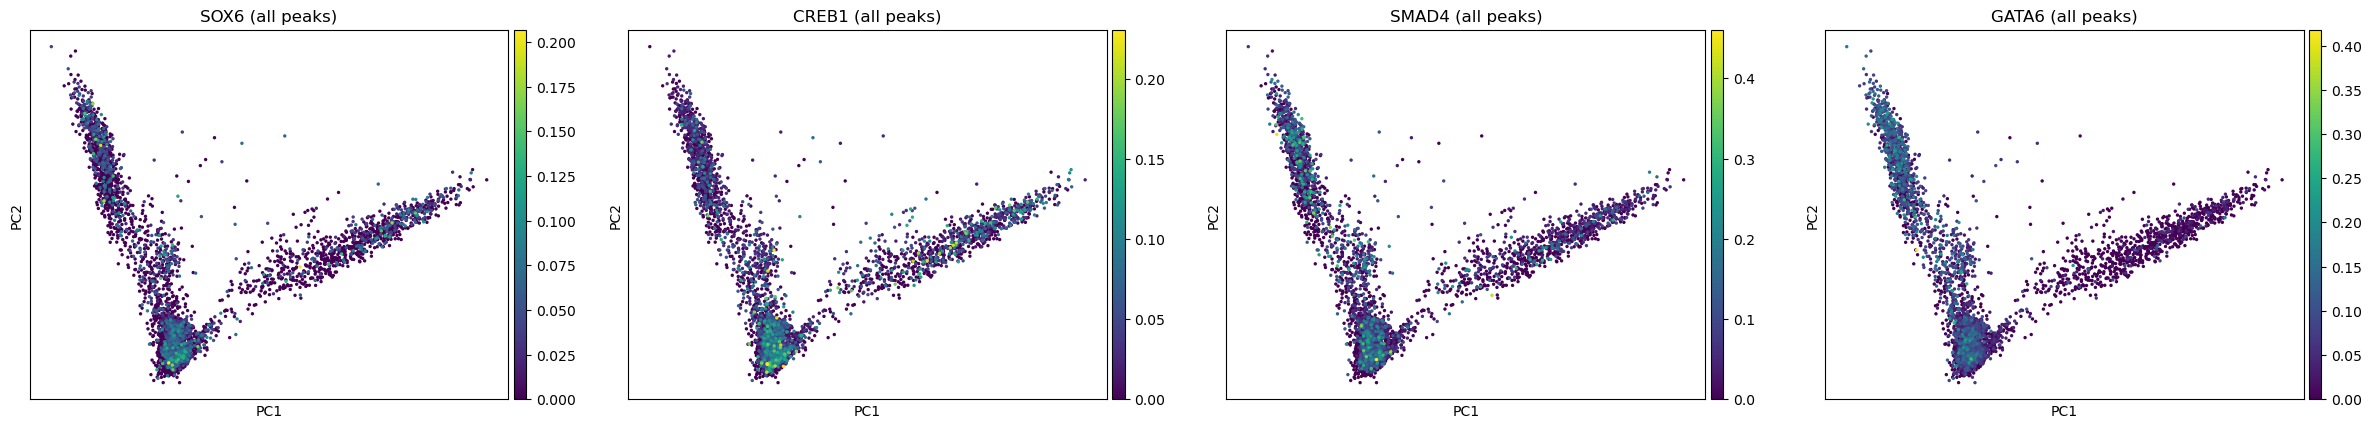

In [43]:
ac.pl.pca(atac, color=['SOX6', 'CREB1', 'SMAD4', 'GATA6'], average="total")

We can also average peaks of each type separately:

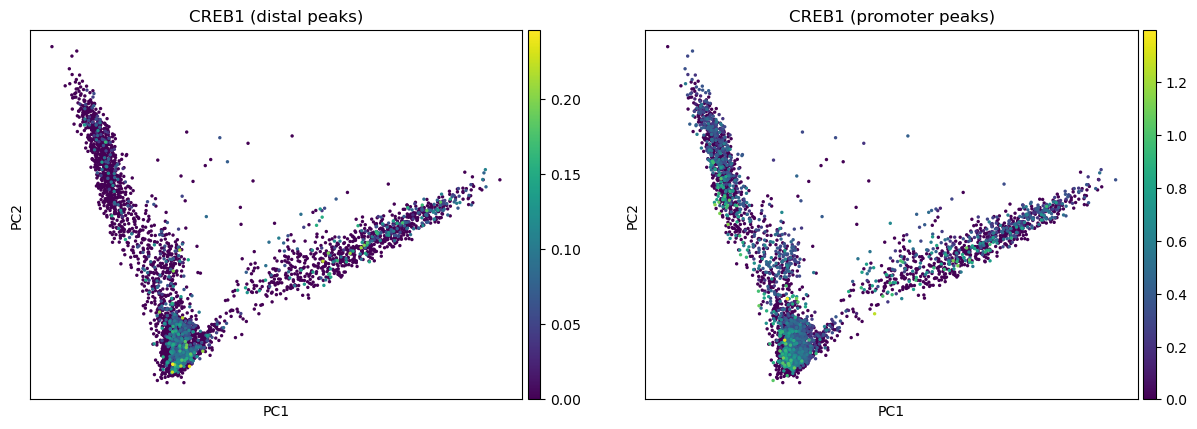

In [44]:
ac.pl.pca(atac, color='CREB1', average="peak_type")

We see how this component space here resembles the one based on gene expression from the previous notebook. Now we will compute a neighbourhood graph for cells that we’ll use for clustering later on.

### Neighbors

In [45]:
sc.pp.neighbors(atac, n_neighbors=10, n_pcs=30)

### Non-linear dimensionality reduction and clustering

To stay comparable to the gene expression notebook, we will use leiden to cluster cells. We’ll use UMAP latent space for visualisation below.

In [46]:
sc.tl.umap(atac, spread=1., min_dist=.5, random_state=11)
sc.tl.leiden(atac, flavor="igraph", n_iterations=2)

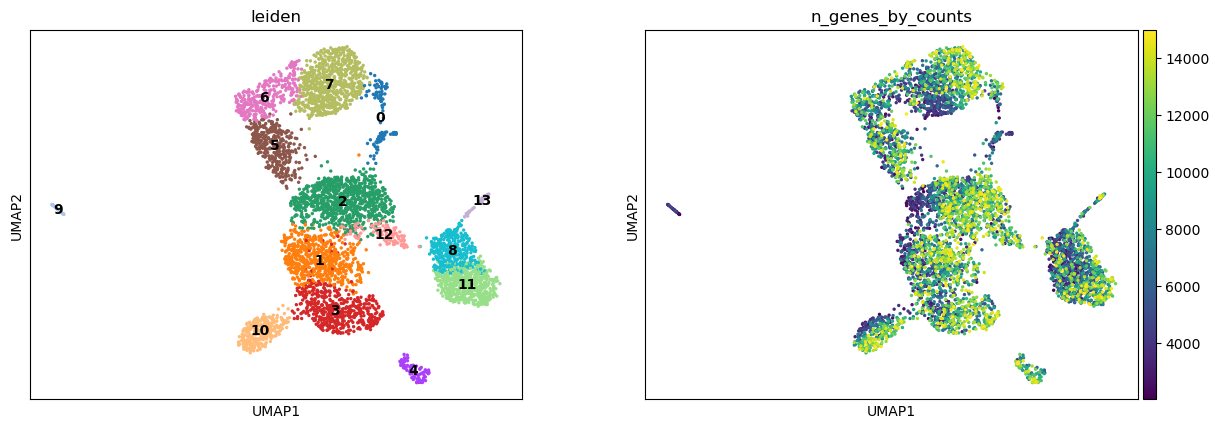

In [47]:
sc.pl.umap(atac, color=["leiden", "n_genes_by_counts"], legend_loc="on data")

Again, we can use the functionality of the ATAC module in muon to color plots by cut values in peaks correspoonding to a certain gene:

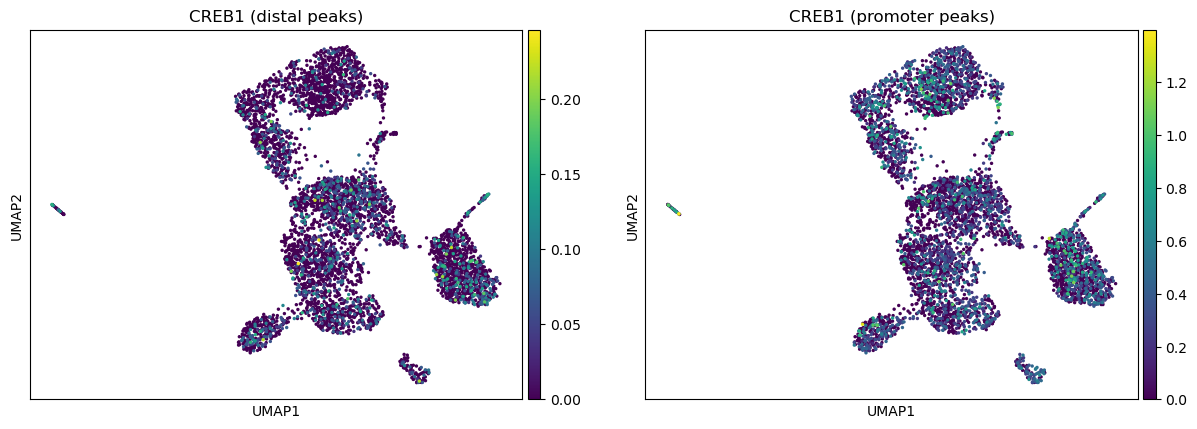

In [48]:
ac.pl.umap(atac, color=["CREB1"], average="peak_type")

### Marker Genes and Celltypes

We will now define cell types based on chromatin accessibility.

In [49]:
ac.tl.rank_peaks_groups(atac, 'leiden', method='t-test')

In [50]:
result = atac.uns["rank_genes_groups"]
groups = result["names"].dtype.names

pd.set_option("display.max_columns", 50)

df = pd.DataFrame({
    f"{group}_{key[:1]}": pd.Series(result[key][group])
    for group in groups
    for key in ["names", "genes", "pvals"]
    if key in result
})

df.head(10)

,0_n,0_g,0_p,1_n,1_g,1_p,2_n,2_g,2_p,3_n,3_g,3_p,4_n,4_g,4_p,5_n,5_g,5_p,6_n,6_g,6_p,7_n,7_g,7_p,8_n,8_g,8_p,9_n,9_g,9_p,10_n,10_g,10_p,11_n,11_g,11_p,12_n,12_g,12_p,13_n,13_g,13_p
0,chr11:109011392-109012310,AXIN2,1.206588e-55,chr7:96440190-96441033,GM15412,5.307560e-39,chr6:70963820-70964750,FOXI3,1.058158e-45,chr2:180354577-180355494,GATA5,5.305464e-38,chr11:88968112-88968998,ELOBL,6.097927e-29,chr6:34725783-34726638,AGBL3,1.873893e-21,JH584304.1:59277-60151,SFI1,8.259276e-48,chr11:3192896-3193788,SFI1,1.682074e-180,chr11:3192896-3193788,SFI1,1.583760e-94,chr6:51469792-51470563,"CBX3, HNRNPA2B1",2.854063e-07,chr15:25608758-25609701,MYO10,1.044621e-29,chr11:3192896-3193788,SFI1,5.304826e-132,chr2:60196633-60197496,MARCHF7,3.333112e-09,chr11:3192896-3193788,SFI1,3.007454e-11
1,chr13:9011379-9012248,GTPBP4,9.538307e-55,chr2:26486548-26487436,NOTCH1,3.217534e-38,chr5:116950227-116951168,SUDS3,2.212045e-43,chr9:54783770-54784670,CRABP1,1.081738e-37,chr2:124465450-124466360,EPAS1,5.001101e-21,chr12:25011426-25012329,KIDINS220,7.277041e-19,chr11:3192896-3193788,NOSTRIN,1.359677e-30,JH584304.1:59277-60151,MROH2A,9.811103e-143,JH584304.1:59277-60151,FRS2,3.532760e-58,chr11:69758131-69759186,POLR2A,8.190092e-07,chr1:168287857-168288726,PBX1,5.187128e-29,chr12:25144520-25145429,GM17746,6.608340e-68,chr8:120425183-120426087,GSE1,4.641603e-09,chr15:78493616-78494525,IL2RB,2.896717e-08
2,chr3:5860218-5861113,GM8579,6.282041e-54,chr15:79307846-79308677,PLA2G6,3.303727e-36,chr10:116561982-116562887,CNOT2,1.767186e-42,chr4:13264987-13265846,GM4265,1.482828e-36,chr17:86740938-86741863,E330020D12RIK,3.732591e-20,chr5:75377121-75378013,KIT,4.020312e-17,chr2:69132008-69132862,FLRT3,2.162273e-20,JH584304.1:42925-43751,TSPAN18,1.081949e-110,chr10:117166942-117167857,GM10532,7.566396e-36,chr16:22008984-22009849,SENP2,9.170982e-07,chr5:128541818-128542685,FZD10OS,8.726691e-29,chr11:88968112-88968998,ELOBL,1.233546e-63,chr13:40649416-40650289,GM26688,2.161584e-08,chr15:62060079-62060884,PVT1,5.000156e-08
3,chr6:3201029-3201917,CDK8,1.057770e-52,chr8:121313390-121314305,FOXL1,3.581651e-34,chr13:112985477-112986409,CCNO,1.755370e-39,chr7:129790483-129791385,HAND1,6.407397e-34,chr1:153376287-153377227,PRSS55,5.058949e-20,chr15:101853955-101854889,KRT1,4.697578e-17,chr2:140748364-140749297,PDLIM5,1.131953e-19,JH584304.1:38335-39236,SPNS2,1.016858e-102,chr18:75498688-75499613,GM17746,6.542904e-27,GL456216.1:15625-16542,STK11,1.185183e-06,chr9:71606315-71607156,MYZAP,5.028980e-28,chr3:121558982-121559909,SLC44A3,8.946821e-56,chr7:79543293-79544184,GM51285,3.121070e-08,chr5:134680153-134680969,LIMK1,6.798244e-08
4,chr5:146260721-146261628,FILIP1L,1.075378e-52,chr7:126784863-126785714,TBX6,3.193018e-34,chr1:88668574-88669492,ARL4C,1.559695e-39,chr11:57903926-57904853,KIF26B,1.279731e-32,chr17:86536473-86537102,A730020M07RIK,2.224596e-19,chr11:8985938-8986759,HUS1,3.025126e-16,chr3:142348724-142349629,NDUFB4,3.967973e-19,chr1:88237139-88238025,PIP5K1C,4.767852e-96,chr12:25144520-25145429,GM51276,6.448788e-26,chr10:80115193-80116097,"SAFB, SAFB2",1.341368e-06,chr1:36919897-36920837,TMEM131,1.180261e-27,chr9:118397553-118398473,4933432G23RIK,2.249205e-53,chr11:117603832-117604715,2900041M22RIK,3.630928e-08,chr5:65746760-65747666,N4BP2,1.630186e-07
5,chr16:57391114-57392011,ZC3H7A,1.415861e-52,chr9:21249718-21250624,S1PR5,4.720313e-34,chr17:27501456-27502359,GRM4,2.322577e-38,chr1:178661221-178662053,TBX3,2.896537e-32,chr14:64055008-64055947,LAMB1,6.249457e-19,chr11:68285634-68286458,MIR6406,3.574442e-16,chr16:37623669-37624588,TMPRSS2,4.545505e-18,chr2:93261788-93262706,BEND3,9.298513e-73,chr4:150748006-150748907,CRLF2,6.640411e-24,chr17:56584330-56585261,HMGB2,1.892765e-06,chr19:10661161-10662097,4930524O05RIK,6.347546e-27,chr3:144213713-144214635,LMO4,3.608425e-53,chr11:103772122-103772931,WNT3,4.441463e-08,chr9:55128769-55129635,UBE2Q2,2.215308e-07
6,chr16:11143652-11144551,RPP21,6.847501e-52,chr17:15440391-15441307,FAM120B,1.609779e-33,chr4:117373423-11737

## Saving progress to disk

In [51]:
mu.write(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu/atac"), atac)

---

# Integrating Gene Expression and Chromatin Accessibility

In this section, we will see how to learn a latent space jointly on two omics.

In [52]:
mdata = mu.read(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu"))
mdata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 7271 × 223768
  var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  2 modalities
    rna:	5063 x 23883
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    atac:	5000 x 199885
      obs:	'n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal', 'tss_score', 'n_counts', 'leiden'
      var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'atac', 'files', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In each modality, only cells passing respective QC are retained. For the multimodal data integration, we will use only cells that are present for both modalities:

In [53]:
mu.pp.intersect_obs(mdata)
mdata.shape

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


(2792, 223768)

## Perform Integration

We will now run multi-omic factor analysis — a group factor analysis method that will allow us to learn an interpretable latent space jointly on both modalities. Intuitively, it can be viewed as a generalisation of PCA for multi-omics data. More information about this method can be found on the MOFA website.

The time required to train the model depends on the number of cells and features as well as on hardware specs. For the current dataset, it takes 4 minutes on the GeForce RTX 2080 Ti NVIDIA card. Only highly variable features are used by default.

In [54]:
mu.tl.mofa(mdata, outfile=SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}_rna_atac.h5mu")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='rna' group='group1' with N=2792 samples and D=3310 features...
Loaded view='atac' group='group1' with N=2792 samples and D=16956 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Li

After the training, the embedding will be added to the `obsm` slot of the `mdata`:

In [55]:
mdata.obsm['X_mofa'].shape

(2792, 10)

To visualise all the factors together, we’ll use a non-linear dimensionality reduction method such as UMAP to display the embedding in 2D:

In [56]:
sc.pp.neighbors(mdata, use_rep="X_mofa")
sc.tl.umap(mdata)

In [57]:
sc.tl.umap(mdata, min_dist=.2, spread=1., random_state=10)

Conventional clustering can now be performed based on the MOFA embeddings and also can be visualised on the same UMAP:

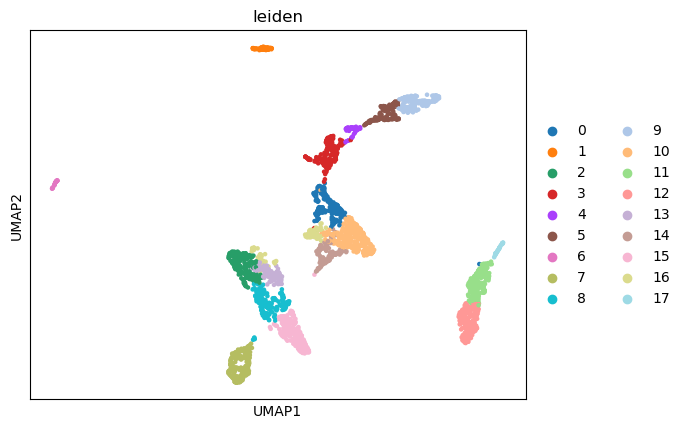

In [58]:
sc.tl.leiden(mdata, flavor="igraph", n_iterations=2)
sc.pl.umap(mdata, color=["leiden"])

Individual features from modalities are also available when plotting embeddings:

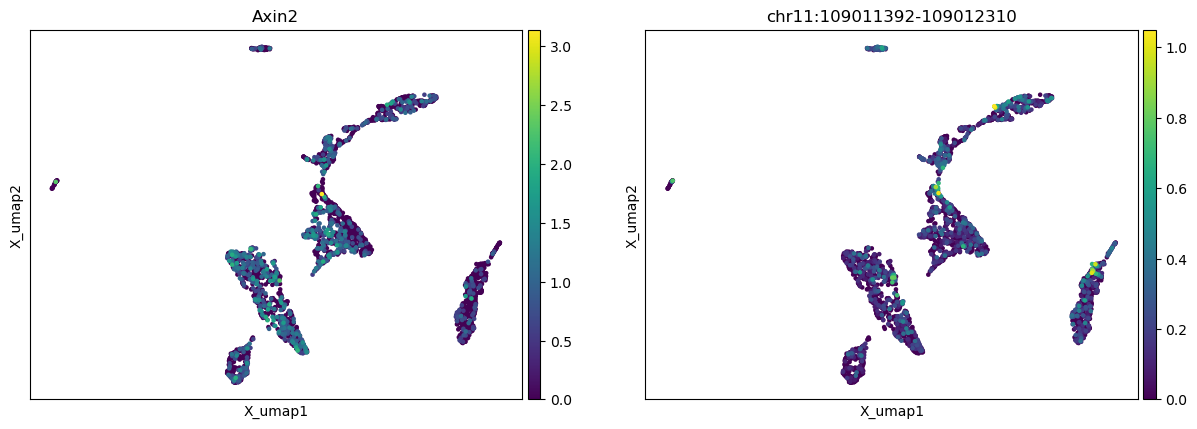

In [60]:
mu.pl.umap(mdata, color=["Axin2", "chr11:109011392-109012310"])

We can also generate custom plots with matplotlib and seaborn:

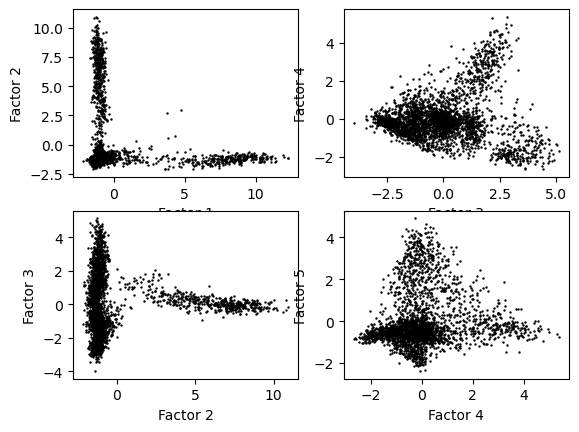

In [61]:
df = pd.DataFrame(mdata.obsm["X_mofa"])
df.columns = [f"Factor {i+1}" for i in range(df.shape[1])]

plot_scatter = lambda i, ax: sns.scatterplot(data=df, x=f"Factor {i+1}", y=f"Factor {i+2}", color="black", linewidth=0, s=3, ax=ax)

fig, axes = plt.subplots(2, 2)
for i in range(4):
    plot_scatter(i, axes[i%2][i//2])

## Ranking genes and peaks

In [65]:
mdata["rna"].obs["leiden_joint"] = mdata.obs["leiden"]
mdata["atac"].obs["leiden_joint"] = mdata.obs["leiden"]

In [66]:
sc.tl.rank_genes_groups(mdata['rna'], 'leiden_joint', method='t-test_overestim_var')

In [67]:
ac.tl.rank_peaks_groups(mdata['atac'], 'leiden_joint', method='t-test_overestim_var')

## Listing differentially expressed genes and differentially accessible peaks

In [70]:
result = {}
result['rna'] = mdata['rna'].uns['rank_genes_groups']
result['rna']['genes'] = result['rna']['names']
result['atac'] = mdata['atac'].uns['rank_genes_groups']

groups = result['rna']['names'].dtype.names
pd.set_option("display.max_columns", 200)
pd.DataFrame(
    {mod + ':' + group + '_' + key[:1]: pd.Series(result[mod][key][group])[:10]
    for group in groups for key in ['names', 'genes', 'pvals']
    for mod in mdata.mod.keys()})

,rna:0_n,atac:0_n,rna:0_g,atac:0_g,rna:0_p,atac:0_p,rna:1_n,atac:1_n,rna:1_g,atac:1_g,rna:1_p,atac:1_p,rna:2_n,atac:2_n,rna:2_g,atac:2_g,rna:2_p,atac:2_p,rna:3_n,atac:3_n,rna:3_g,atac:3_g,rna:3_p,atac:3_p,rna:4_n,atac:4_n,rna:4_g,atac:4_g,rna:4_p,atac:4_p,rna:5_n,atac:5_n,rna:5_g,atac:5_g,rna:5_p,atac:5_p,rna:6_n,atac:6_n,rna:6_g,atac:6_g,rna:6_p,atac:6_p,rna:7_n,atac:7_n,rna:7_g,atac:7_g,rna:7_p,atac:7_p,rna:8_n,atac:8_n,rna:8_g,atac:8_g,rna:8_p,atac:8_p,rna:9_n,atac:9_n,rna:9_g,atac:9_g,rna:9_p,atac:9_p,rna:10_n,atac:10_n,rna:10_g,atac:10_g,rna:10_p,atac:10_p,rna:11_n,atac:11_n,rna:11_g,atac:11_g,rna:11_p,atac:11_p,rna:12_n,atac:12_n,rna:12_g,atac:12_g,rna:12_p,atac:12_p,rna:13_n,atac:13_n,rna:13_g,atac:13_g,rna:13_p,atac:13_p,rna:14_n,atac:14_n,rna:14_g,atac:14_g,rna:14_p,atac:14_p,rna:15_n,atac:15_n,rna:15_g,atac:15_g,rna:15_p,atac:15_p,rna:16_n,atac:16_n,rna:16_g,atac:16_g,rna:16_p,atac:16_p,rna:17_n,atac:17_n,rna:17_g,atac:17_g,rna:17_p,atac:17_p
0,Rps8,chr5:116950227-116951168,Rps8,SUDS3,6.695804e-12,0.000002,Lama1,chr11:88968112-88968998,Lama1,ELOBL,1.756231e-66,4.746321e-23,Tenm4,chr2:26486548-26487436,Tenm4,NOTCH1,2.713496e-117,6.385329e-19,9030622O22Rik,chr12:25011426-25012329,9030622O22Rik,KIDINS220,5.750122e-39,8.904740e-13,Tmprss2,chr11:3192896-3193788,Tmprss2,SFI1,1.116637e-15,0.000003,Cubn,chr11:3192896-3193788,Cubn,SFI1,3.113097e-45,6.213967e-23,Ptprc,chr16:22008984-22009849,Ptprc,SENP2,1.662830e-08,3.702881e-07,Fli1,chr1:168287857-168288726,Fli1,PBX1,5.403883e-59,5.507152e-24,Cdh2,chr11:57903926-57904853,Cdh2,HAND1,8.376747e-20,4.098349e-08,Cubn,JH584304.1:42925-43751,Cubn,MROH2A,8.456907e-125,1.385663e-33,Dnmt3b,chr10:116561982-116562887,Dnmt3b,CNOT2,5.657798e-82,1.058474e-15,Sfmbt2,chr11:3192896-3193788,Sfmbt2,SFI1,6.389168e-56,1.271777e-55,Ranbp17,chr11:3192896-3193788,Ranbp17,SFI1,7.259831e-75,3.432170e-37,Pcdh19,chr9:102573721-102574608,Pcdh19,CEP63,1.352484e-20,1.331578e-07,Foxp1,chr6:70899331-70900234,Foxp1,TEX37,1.181377e-26,1.255343e-08,Unc5c,chr11:63023844-63024708,Unc5c,CDRT4OS1,4.765982e-151,5.005228e-19,T,chr1:77422317-77423231,T,MIR6352,6.058631e-36,0.000018,Plac1,chr11:3192896-3193788,Plac1,SFI1,1.606218e-18,6.275052e-08
1,Ptma,chr9:94661500-94662413,Ptma,SLC9A9,2.623870e-11,0.000008,Lamc1,chr2:124465450-124466360,Lamc1,E330020D12RIK,3.261293e-63,1.977021e-18,Lef1,chr15:79307846-79308677,Lef1,PLA2G6,1.612337e-80,1.488895e-17,Ap1s3,chr6:34725783-34726638,Ap1s3,AGBL3,3.583498e-38,3.946972e-12,9030622O22Rik,chr12:104998603-104999358,9030622O22Rik,SYNE3,1.291468e-13,0.000014,Apob,JH584304.1:59277-60151,Apob,C9,1.046861e-43,1.389133e-19,B2m,chr6:51469792-51470563,B2m,"CBX3, HNRNPA2B1",9.494108e-08,1.054837e-06,Runx1,chr8:72268080-72269010,Runx1,AP1M1,2.212787e-62,5.358510e-22,Fn1,chr9:54783770-54784670,Fn1,CRABP1,3.875115e-19,7.173490e-08,Dab2,JH584304.1:38335-39236,Dab2,SFI1,1.024532e-90,5.826686e-32,Bmpr1b,chr12:12926897-12927832,Bmpr1b,MYCN,5.075782e-67,2.890924e-14,Gjb3,JH584304.1:59277-60151,Gjb3,FRS2,2.767149e-35,5.435540e-33,Rbm20,chr11:88968112-88968998,Rbm20,ELOBL,4.417928e-72,6.784353e-33,Fn1,chr13:45213429-45214302,Fn1,MYLIP,8.255564e-19,2.119607e-07,Meis2,chr2:60196633-60197496,Meis2,MARCHF7,3.084807e-23,1.681822e-07,Prdm6,chr9:54783770-54784670,Prdm6,CRABP1,1.007806e-107,1.408427e-18,Slit3,chr18:34551540-34552382,Slit3,WNT8A,4.077253e-26,0.000024,Tfap2c,chr18:74899743-74900636,Tfap2c,LIPG,9.516055e-20,7.790231e-07
2,Elavl3,chr5:147221821-147222672,Elavl3,GSX1,4.839223e-11,0.000023,Nid1,chr1:153376287-153377227,Nid1,A730020M07RIK,1.462673e-68,1.010797e-17,Pcdh19,chr8:121313390-121314305,Pcdh19,FOXL1,5.036424e-77,2.246283e-16,Elmo1,chr12:29960676-29961602,Elmo1,PXDN,2.224835e-33,2.094101e-11,Eda,JH584304.1:59277-60151,Eda,ABHD2,1.413096e-14,0.000017,Dab2,chr15:6374874-6375782,Dab2,AGFG1,9.018602e-44,1.061701e-09,AY036118,GL456216.1:15625-16542,AY036118,POLR2A,5.628076e-09,2.710234e-06,Reln,chr15:25608758-25609701,Reln,MYO10,8.901801e-60,6.337514e-22,Hmga2,chr10:120572104-120572809,Hmga2,H